In [1]:
# Cocoa Disease Detection - Model Training
# This notebook covers the training process for the YOLOv8 model for cocoa disease detection

# Import dependencies
import os
import sys
import yaml
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import torch
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import time
import shutil
from ultralytics import YOLO
from sklearn.model_selection import train_test_split

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import TRAIN_CSV, TEST_CSV, IMAGES_DIR, MODEL_DIR, OUTPUT_DIR, EPOCHS
from src.models.detector import CocoaDiseaseDetector

In [2]:
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
# Check if data exists
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
print(f"Test CSV exists: {os.path.exists(TEST_CSV)}")
print(f"Images directory exists: {os.path.exists(IMAGES_DIR)}")

Train CSV exists: True
Test CSV exists: True
Images directory exists: True


In [5]:
# 1. Load and explore the dataset
# --------------------------------------------------

# Load the training data
train_df = pd.read_csv(TRAIN_CSV)
print(f"Training data shape: {train_df.shape}")
train_df.head()

Training data shape: (9792, 9)


,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg


In [6]:
# Check class distribution
class_counts = train_df['class'].value_counts()
print("\nClass distribution:")
print(class_counts)


Class distribution:
healthy        4280
cssvd          3241
anthracnose    2271
Name: class, dtype: int64


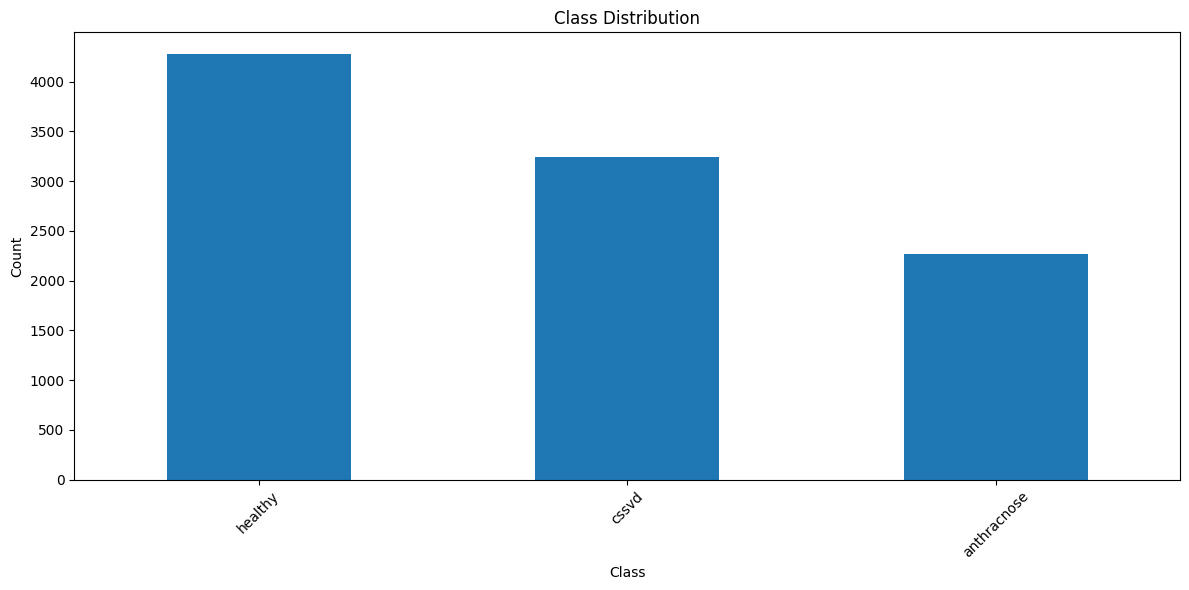

In [7]:
# Plot class distribution
plt.figure(figsize=(12, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Check number of unique images
unique_images = train_df['Image_ID'].nunique()
print(f"\nNumber of unique images in training data: {unique_images}")


Number of unique images in training data: 5529


In [9]:
# Check number of boxes per image
boxes_per_image = train_df.groupby('Image_ID').size()
print(f"\nBoxes per image statistics:")
print(f"Mean: {boxes_per_image.mean():.2f}")
print(f"Median: {boxes_per_image.median():.2f}")
print(f"Max: {boxes_per_image.max():.2f}")
print(f"Min: {boxes_per_image.min():.2f}")


Boxes per image statistics:
Mean: 1.77
Median: 1.00
Max: 13.00
Min: 1.00


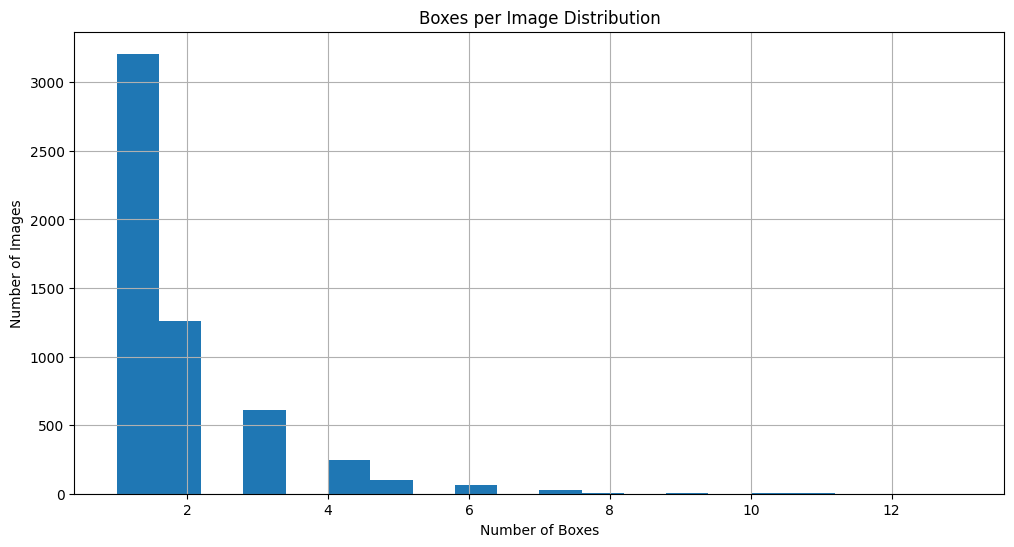

In [10]:
# Plot boxes per image distribution
plt.figure(figsize=(12, 6))
plt.hist(boxes_per_image, bins=20)
plt.title('Boxes per Image Distribution')
plt.xlabel('Number of Boxes')
plt.ylabel('Number of Images')
plt.grid(True)
plt.show()

In [21]:
# 2. Prepare YOLO Dataset
# --------------------------------------------------

def prepare_yolo_dataset(train_df, images_dir, output_dir, test_size=0.3):
    """
    Prepare YOLO dataset from the training DataFrame.

    Args:
        train_df (pd.DataFrame): DataFrame containing training data with columns ['Image_ID', 'class', 'x_min', 'y_min', 'x_max', 'y_max'].
        images_dir (str): Directory containing the images.
        output_dir (str): Directory to save the YOLO dataset.
        test_size (float): Proportion of the dataset to include in the test split.
    
    Returns:
        str: Path to the dataset.yaml file.
    """
    print("Preparing YOLO dataset...")

    classes = train_df['class'].unique().tolist()
    print(f"Classes: {classes}")

    image_ids = train_df['Image_ID'].unique()
    print(f"Number of unique images: {len(image_ids)}")

    train_ids, val_ids = train_test_split(image_ids, test_size=test_size, random_state=42)
    print(f"Training images: {len(train_ids)}")
    print(f"Validation images: {len(val_ids)}")

    dataset_dir = os.path.join(output_dir, 'dataset')
    os.makedirs(dataset_dir, exist_ok=True)

    train_labels_dir = os.path.join(dataset_dir, 'train', 'labels')
    val_labels_dir = os.path.join(dataset_dir, 'val', 'labels')
    train_images_dir = os.path.join(dataset_dir, 'train', 'images')
    val_images_dir = os.path.join(dataset_dir, 'val', 'images')

    os.makedirs(train_labels_dir, exist_ok=True)
    os.makedirs(val_labels_dir, exist_ok=True)
    os.makedirs(train_images_dir, exist_ok=True)
    os.makedirs(val_images_dir, exist_ok=True)

    print("Processing training images...")
    for img_id in tqdm(train_ids):
        img_path = os.path.join(images_dir, img_id)

        if not os.path.exists(img_path):
            print(f"Image not found: {img_path}")
            continue

        dest_path = os.path.join(train_images_dir, img_id)
        if not os.path.exists(dest_path):
            try:
                os.symlink(os.path.abspath(img_path), dest_path)
            except (OSError, AttributeError):
                shutil.copy2(img_path, dest_path)
        
        annotations = train_df[train_df['Image_ID'] == img_id]

        label_file = os.path.splitext(img_id)[0] + '.txt'
        label_path = os.path.join(train_labels_dir, label_file)

        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to read image: {img_path}")
            continue

        height, width, _ = img.shape

        with open(label_path, 'w') as f:
            for _, row in annotations.iterrows():
                class_idx = classes.index(row['class'])

                x_min = float(row['xmin']) / width
                y_min = float(row['ymin']) / height
                x_max = float(row['xmax']) / width
                y_max = float(row['ymax']) / height

                x_min = max(0, min(1, x_min))
                y_min = max(0, min(1, y_min))
                x_max = max(0, min(1, x_max))
                y_max = max(0, min(1, y_max))

                if x_max <= x_min or y_max <= y_min:
                    print(f"Invalid bounding box for image {img_id}: ({x_min}, {y_min}, {x_max}, {y_max})")
                    continue


                center_x = (x_min + x_max) / 2
                center_y = (y_min + y_max) / 2
                bbox_width = x_max - x_min
                bbox_height = y_max - y_min

                f.write(f"{class_idx} {center_x} {center_y} {bbox_width} {bbox_height}\n")

    print("Processing validation images...")
    for img_id in tqdm(val_ids):
        img_path = os.path.join(images_dir, img_id)

        if not os.path.exists(img_path):
            print(f"Image not found: {img_path}")
            continue

        dest_path = os.path.join(val_images_dir, img_id)
        if not os.path.exists(dest_path):
            try:
                os.symlink(os.path.abspath(img_path), dest_path)
            except (OSError, AttributeError):
                shutil.copy2(img_path, dest_path)

        annotations = train_df[train_df['Image_ID'] == img_id]

        label_file = os.path.splitext(img_id)[0] + '.txt'
        label_path = os.path.join(val_labels_dir, label_file)

        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to read image: {img_path}")
            continue
        
        height, width, _ = img.shape

        with open(label_path, 'w') as f:
            for _, row in annotations.iterrows():
                class_idx = classes.index(row['class'])

                x_min = float(row['xmin']) / width
                y_min = float(row['ymin']) / height
                x_max = float(row['xmax']) / width
                y_max = float(row['ymax']) / height

                x_min = max(0, min(1, x_min))
                y_min = max(0, min(1, y_min))
                x_max = max(0, min(1, x_max))
                y_max = max(0, min(1, y_max))

                if x_max <= x_min or y_max <= y_min:
                    print(f"Invalid bounding box for image {img_id}: ({x_min}, {y_min}, {x_max}, {y_max})")
                    continue

                center_x = (x_min + x_max) / 2
                center_y = (y_min + y_max) / 2
                bbox_width = x_max - x_min
                bbox_height = y_max - y_min

                f.write(f"{class_idx} {center_x} {center_y} {bbox_width} {bbox_height}\n")

    dataset_yaml = os.path.join(dataset_dir, 'dataset.yaml')

    yaml_data = {
        'path': os.path.abspath(dataset_dir),
        'train': 'train/images',
        'val': 'val/images',
        'nc': len(classes),
        'names': classes
    }

    with open(dataset_yaml, 'w') as f:
        yaml.safe_dump(yaml_data, f, sort_keys=False)

    print(f"Dataset YAML file created at: {dataset_yaml}")
    return dataset_yaml

        

In [22]:
dataset_yaml = prepare_yolo_dataset(train_df, IMAGES_DIR, OUTPUT_DIR)

Preparing YOLO dataset...
Classes: ['healthy', 'anthracnose', 'cssvd']
Number of unique images: 5529
Training images: 3870
Validation images: 1659
Processing training images...


  0%|          | 0/3870 [00:00<?, ?it/s]

Processing validation images...


  0%|          | 0/1659 [00:00<?, ?it/s]

Dataset YAML file created at: /Users/victoroko/Documents/cocoa-disease-detection/output/dataset/dataset.yaml


In [28]:
# 3. Train the YOLOv8 model
# --------------------------------------------------

def train_yolo_model(dataset_yaml, model_name='yolov8n.pt', epochs=100, patience=20, img_size=640, batch_size=-1):
    """
    Train YOLOv8 model
    
    Args:
        dataset_yaml (str): Path to dataset.yaml
        model_name (str): Model name/path
        epochs (int): Number of epochs
        patience (int): Early stopping patience
        img_size (int): Image size
        batch_size (int): Batch size (-1 for auto)
    
    Returns:
        str: Path to best trained model
    """
    print(f"Training YOLOv8 model: {model_name}")
    
    model = YOLO(model_name)
    
    results = model.train(
        data=dataset_yaml,
        epochs=epochs,
        patience=patience,
        imgsz=img_size,
        batch=batch_size,
        optimizer='AdamW',
        lr0=1e-3,
        lrf=1e-4,
        momentum=0.937,
        weight_decay=5e-4,
        warmup_epochs=3.0,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        box=7.5,
        cls=0.5,
        dfl=1.5,
        label_smoothing=0.0,
        nbs=64,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        translate=0.1,
        scale=0.5,
        shear=0.0,
        perspective=0.0,
        flipud=0.0,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.0,
        copy_paste=0.0,
        auto_augment='randaugment',
        erasing=0.0,
        project=os.path.join(OUTPUT_DIR, 'training'),
        name='yolov8_cocoa',
        exist_ok=True,
        pretrained=True,
        verbose=True,
        seed=42,
        deterministic=True,
        device=0 if torch.cuda.is_available() else 'cpu',
        save=True,
        save_period=-1,
        cache=False
    )
    
    best_model_path = model.best
    print(f"Best model saved to: {best_model_path}")
    
    os.makedirs(MODEL_DIR, exist_ok=True)
    dest_path = os.path.join(MODEL_DIR, 'best.pt')
    shutil.copy2(best_model_path, dest_path)
    print(f"Best model copied to: {dest_path}")
    
    return dest_path

In [29]:
model_variants = {
    'yolov8n.pt': 'Nano (fastest)',
    'yolov8s.pt': 'Small (balanced)',
    'yolov8m.pt': 'Medium (higher accuracy)'
}

print("Available model variants:")
for model, description in model_variants.items():
    print(f"- {model}: {description}")

Available model variants:
- yolov8n.pt: Nano (fastest)
- yolov8s.pt: Small (balanced)
- yolov8m.pt: Medium (higher accuracy)


In [30]:
selected_model = 'yolov8n.pt'  # Nano for mobile efficiency
print(f"Selected model: {selected_model}")

Selected model: yolov8n.pt


In [31]:
start_time = time.time()
best_model_path = train_yolo_model(
    dataset_yaml=dataset_yaml,
    model_name=selected_model,
    epochs=50,  # Reduced for notebook demonstration
    patience=10,
    img_size=640,
    batch_size=16  # Set explicitly for reproducibility
)
training_time = time.time() - start_time
print(f"Training completed in {training_time/60:.2f} minutes")

Training YOLOv8 model: yolov8n.pt
New https://pypi.org/project/ultralytics/8.3.130 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.81 🚀 Python-3.9.13 torch-1.13.1 CPU (Apple M2)
WARNING ⚠️ Upgrade to torch>=2.0.0 for deterministic training.
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/Users/victoroko/Documents/cocoa-disease-detection/output/dataset/dataset.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=/Users/victoroko/Documents/cocoa-disease-detection/output/training, name=yolov8_cocoa, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, h

[W NNPACK.cpp:53] Could not initialize NNPACK! Reason: Unsupported hardware.


Model summary: 225 layers, 3,011,433 parameters, 3,011,417 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights


: 

In [1]:
# 4. Validate model performance
# ------------------------------------------

def validate_model(model_path, dataset_yaml):
    """
    Validate model performance
    
    Args:
        model_path (str): Path to model
        dataset_yaml (str): Path to dataset.yaml
    
    Returns:
        dict: Validation metrics
    """
    print(f"Validating model: {model_path}")
    
    model = YOLO(model_path)
    
    results = model.val(data=dataset_yaml)
    
    return results


In [ ]:
validation_results = validate_model(best_model_path, dataset_yaml)

In [ ]:
print("\nValidation Metrics:")
print(f"mAP@0.5: {validation_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {validation_results.box.map:.4f}")
print(f"Precision: {validation_results.box.p:.4f}")
print(f"Recall: {validation_results.box.r:.4f}")
print(f"F1-Score: {2 * (validation_results.box.p * validation_results.box.r) / (validation_results.box.p + validation_results.box.r):.4f}")


In [2]:
# 5. Export model for deployment
# ------------------------------------------

def export_model(model_path, format='onnx', half=True):
    """
    Export model to specified format
    
    Args:
        model_path (str): Path to model
        format (str): Export format
        half (bool): Whether to use half precision
    
    Returns:
        str: Path to exported model
    """
    print(f"Exporting model to {format} format...")
    
    model = YOLO(model_path)
    
    exported_path = model.export(format=format, half=half)
    
    print(f"Model exported to: {exported_path}")
    return exported_path

In [ ]:
formats = ['onnx', 'tflite']

for format in formats:
    exported_path = export_model(best_model_path, format=format, half=True)

In [3]:
# 6. Analyze model performance on different disease classes
# ------------------------------------------

def analyze_class_performance(model_path, dataset_yaml):
    """
    Analyze model performance per class
    
    Args:
        model_path (str): Path to model
        dataset_yaml (str): Path to dataset.yaml
    """
    print("Analyzing performance by class...")
    
    model = YOLO(model_path)
    
    with open(dataset_yaml, 'r') as f:
        dataset_data = yaml.safe_load(f)
    
    class_names = dataset_data['names']
    
    results = model.val(data=dataset_yaml, verbose=True)
    
    print("\nPer-class Performance:")
    for i, name in enumerate(class_names):
        if hasattr(results, 'metrics') and 'class_result' in results.metrics:
            class_metric = results.metrics['class_result'][i]
            print(f"Class: {name}")
            print(f"  Precision: {class_metric.get('precision', 'N/A'):.4f}")
            print(f"  Recall: {class_metric.get('recall', 'N/A'):.4f}")
            print(f"  mAP@0.5: {class_metric.get('map50', 'N/A'):.4f}")
            print(f"  mAP@0.5:0.95: {class_metric.get('map', 'N/A'):.4f}")
        else:
            print(f"Class: {name} - Detailed metrics not available")

In [ ]:
analyze_class_performance(best_model_path, dataset_yaml)

In [ ]:
# 7. Test model on sample images
# ------------------------------------------

def test_on_samples(model_path, images_dir, num_samples=5):
    """
    Test model on sample images
    
    Args:
        model_path (str): Path to model
        images_dir (str): Path to images directory
        num_samples (int): Number of samples to test
    """
    print(f"Testing model on {num_samples} random samples...")
    
    model = YOLO(model_path)
    
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(image_files) > num_samples:
        image_files = np.random.choice(image_files, num_samples, replace=False)
    
    for img_file in image_files:
        img_path = os.path.join(images_dir, img_file)
        
        results = model.predict(img_path, conf=0.25, iou=0.45, save=True, save_crop=True)
        
        result_img = results[0].plot()
        
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title(f'Detections: {img_file}')
        plt.axis('off')
        plt.show()
        
        print(f"\nDetection results for {img_file}:")
        for i, box in enumerate(results[0].boxes):
            cls_id = int(box.cls[0].item())
            cls_name = results[0].names[cls_id]
            conf = box.conf[0].item()
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            print(f"  {i+1}. Class: {cls_name}, Confidence: {conf:.4f}, Box: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")


In [ ]:
test_on_samples(best_model_path, IMAGES_DIR)

In [ ]:
# 8. Monitor resource usage and model size
# ------------------------------------------

def analyze_model_size(model_path):
    """
    Analyze model size and parameters
    
    Args:
        model_path (str): Path to model
    """
    print(f"Analyzing model: {model_path}")
    
    model = YOLO(model_path)
    
    model_size_mb = os.path.getsize(model_path) / (1024 * 1024)
    
    num_params = sum(p.numel() for p in model.model.parameters())
    
    print(f"Model size: {model_size_mb:.2f} MB")
    print(f"Number of parameters: {num_params:,}")
    
    print("\nExported models:")
    export_dir = os.path.dirname(model_path)
    for format in ['onnx', 'tflite']:
        exported_path = os.path.join(export_dir, f"{Path(model_path).stem}.{format}")
        if os.path.exists(exported_path):
            exported_size_mb = os.path.getsize(exported_path) / (1024 * 1024)
            print(f"  {format.upper()} model size: {exported_size_mb:.2f} MB")

analyze_model_size(best_model_path)


In [ ]:
# 9. Measure inference speed
# ------------------------------------------

def measure_inference_speed(model_path, img_size=640, num_runs=50):
    """
    Measure inference speed
    
    Args:
        model_path (str): Path to model
        img_size (int): Image size
        num_runs (int): Number of runs for averaging
    """
    print(f"Measuring inference speed over {num_runs} runs...")
    
    model = YOLO(model_path)
    
    dummy_input = np.random.randint(0, 255, (img_size, img_size, 3), dtype=np.uint8)
    
    for _ in range(10):
        _ = model.predict(dummy_input)
    
    start_time = time.time()
    for _ in range(num_runs):
        _ = model.predict(dummy_input)
    total_time = time.time() - start_time
    
    avg_time_ms = (total_time / num_runs) * 1000
    fps = 1000 / avg_time_ms
    
    print(f"Average inference time: {avg_time_ms:.2f} ms")
    print(f"Frames per second (FPS): {fps:.2f}")
    
    if fps >= 15:
        print("Model is suitable for real-time mobile applications")
    elif fps >= 5:
        print("Model can run on mobile but may not be real-time")
    else:
        print("Model may be too slow for mobile applications")


In [ ]:
measure_inference_speed(best_model_path)

In [ ]:
# 10. Summary and next steps
# ------------------------------------------

print("\n=== Training Summary ===")
print(f"Training time: {training_time/60:.2f} minutes")
print(f"Best model path: {best_model_path}")
print(f"Validation mAP@0.5: {validation_results.box.map50:.4f}")
print(f"Validation mAP@0.5:0.95: {validation_results.box.map:.4f}")
print(f"Dataset: {dataset_yaml}")

print("\n=== Next Steps ===")
print("1. Evaluate model on test set (see 03_model_evaluation.ipynb)")
print("2. Implement explainability (see 04_model_explainability.ipynb)")
print("3. Deploy model to mobile application")
print("4. Monitor model performance in real-world scenarios")